# NB01 — WISDM Dataset Exploration

**Dataset:** WISDM Smartphone and Smartwatch Activity and Biometrics Dataset (Weiss et al., IEEE Access 2019)  
**Subjects:** 51 (IDs 1600–1650) · **Sensor:** phone (acc + gyro) · **Rate:** 20 Hz  
**Activities used:** A = Walking only (gait_only=True)

This notebook mirrors `01_explore_ucihar.ipynb` and produces:
- `logs/wisdm/subject_split.json` — member/non-member split
- `logs/wisdm/auth_pairs.npz` — authentication pairs for NB03/NB04/NB05
- `logs/wisdm/auth_norm_stats.npz` — normalisation stats (saved in NB03)
- LaTeX summary metrics

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import sys
sys.path.insert(0, '..')

import json
import logging
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

from src.data.wisdm_dataset import load_wisdm
from src.data.pair_builder import build_auth_pairs
from src.utils.config_loader import get_dataset
from src.utils.latex_writer import write_latex_metrics

DATASET   = 'wisdm'
DATA_ROOT = Path('../data')
LOG_DIR   = Path('../logs') / DATASET
ARTIFACT_DIR = Path('../artifacts') / DATASET
RESULT_DIR = Path('../results') / DATASET
LOG_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

WISDM_ROOT = DATA_ROOT / 'WISDM'

logging.basicConfig(level=logging.INFO, format='%(message)s')
log = logging.getLogger('nb01_wisdm')
log.info('=== NB01 — WISDM Dataset Exploration ===')

## 1. Load Data

All 51 subjects, walking only. Each window = 128 samples at 20 Hz (6.4 s ≈ 6–7 steps).  
Channels: acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z.

In [3]:
X_all, y_all = load_wisdm(str(WISDM_ROOT), gait_only=True, window=128, stride=64)

all_subjects = sorted(np.unique(y_all).tolist())
log.info(f'Total: {len(y_all)} windows  |  {len(all_subjects)} subjects  |  shape {X_all.shape}')

windows_per_subject = {s: int((y_all == s).sum()) for s in all_subjects}
log.info(f'Windows/subject — min={min(windows_per_subject.values())}  '
         f'max={max(windows_per_subject.values())}  '
         f'mean={np.mean(list(windows_per_subject.values())):.1f}')

Total: 3101 windows  |  51 subjects  |  shape (3101, 6, 128)
Windows/subject — min=54  max=110  mean=60.8


## 2. Subject Split — Members vs Non-Members

40 members (CNN training + auth train pairs), 11 non-members (auth test pairs only).  
Random split seeded at 42 to avoid ordering bias.

In [ ]:
rng = np.random.default_rng(42)
shuffled = rng.permutation(all_subjects).tolist()

N_MEMBERS    = 40
member_ids   = sorted(shuffled[:N_MEMBERS])
nonmember_ids = sorted(shuffled[N_MEMBERS:])

log.info(f'Members     ({len(member_ids)}): {member_ids[:5]}...{member_ids[-5:]}')
log.info(f'Non-members ({len(nonmember_ids)}): {nonmember_ids}')

split = {
    'dataset':      'wisdm',
    'train_ids':    member_ids,
    'held_out_ids': nonmember_ids,
    'n_train':      len(member_ids),
    'n_held_out':   len(nonmember_ids),
}
with open(ARTIFACT_DIR / 'subject_split.json', 'w') as f:
    json.dump(split, f, indent=2)
log.info(f'Saved: {ARTIFACT_DIR}/subject_split.json')

## 3. Windows per Subject

Member windows:     total=2422  min=54  max=110  mean=60.5
Non-member windows: total=679  min=54  max=94  mean=61.7


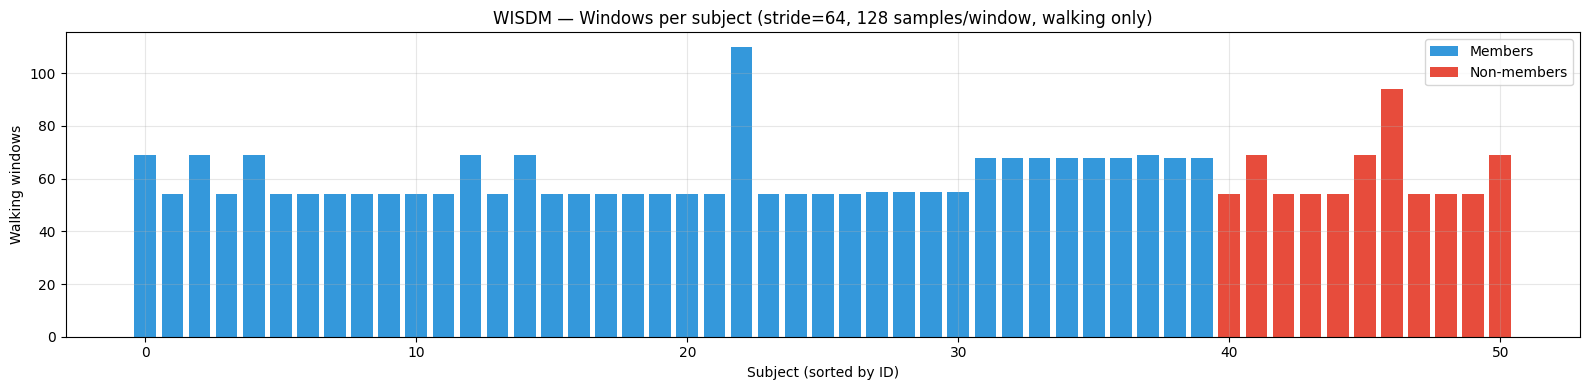

Train: (2422, 6, 128)  |  Test: (679, 6, 128)


In [5]:
X_train = X_all[np.isin(y_all, member_ids)]
y_train = y_all[np.isin(y_all, member_ids)]
X_test  = X_all[np.isin(y_all, nonmember_ids)]
y_test  = y_all[np.isin(y_all, nonmember_ids)]

counts_train = {s: int((y_train == s).sum()) for s in member_ids}
counts_test  = {s: int((y_test  == s).sum()) for s in nonmember_ids}

log.info(f'Member windows:     total={len(y_train)}  min={min(counts_train.values())}  '
         f'max={max(counts_train.values())}  mean={np.mean(list(counts_train.values())):.1f}')
log.info(f'Non-member windows: total={len(y_test)}  min={min(counts_test.values())}  '
         f'max={max(counts_test.values())}  mean={np.mean(list(counts_test.values())):.1f}')

fig, ax = plt.subplots(figsize=(16, 4))
ax.bar(range(len(member_ids)),   list(counts_train.values()), color='#3498db', label='Members')
ax.bar(range(len(member_ids), len(member_ids) + len(nonmember_ids)),
       list(counts_test.values()), color='#e74c3c', label='Non-members')
ax.set_xlabel('Subject (sorted by ID)')
ax.set_ylabel('Walking windows')
ax.set_title('WISDM — Windows per subject (stride=64, 128 samples/window, walking only)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / '01_windows_per_subject.png', dpi=150)
plt.show()
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

## 4. Channel Statistics

  acc_x     mean=+1.3283  std=6.4519
  acc_y     mean=-2.2865  std=8.5255
  acc_z     mean=-0.1695  std=3.8992
  gyr_x     mean=+0.0002  std=1.2883
  gyr_y     mean=+0.0098  std=1.5490
  gyr_z     mean=-0.0126  std=1.0748


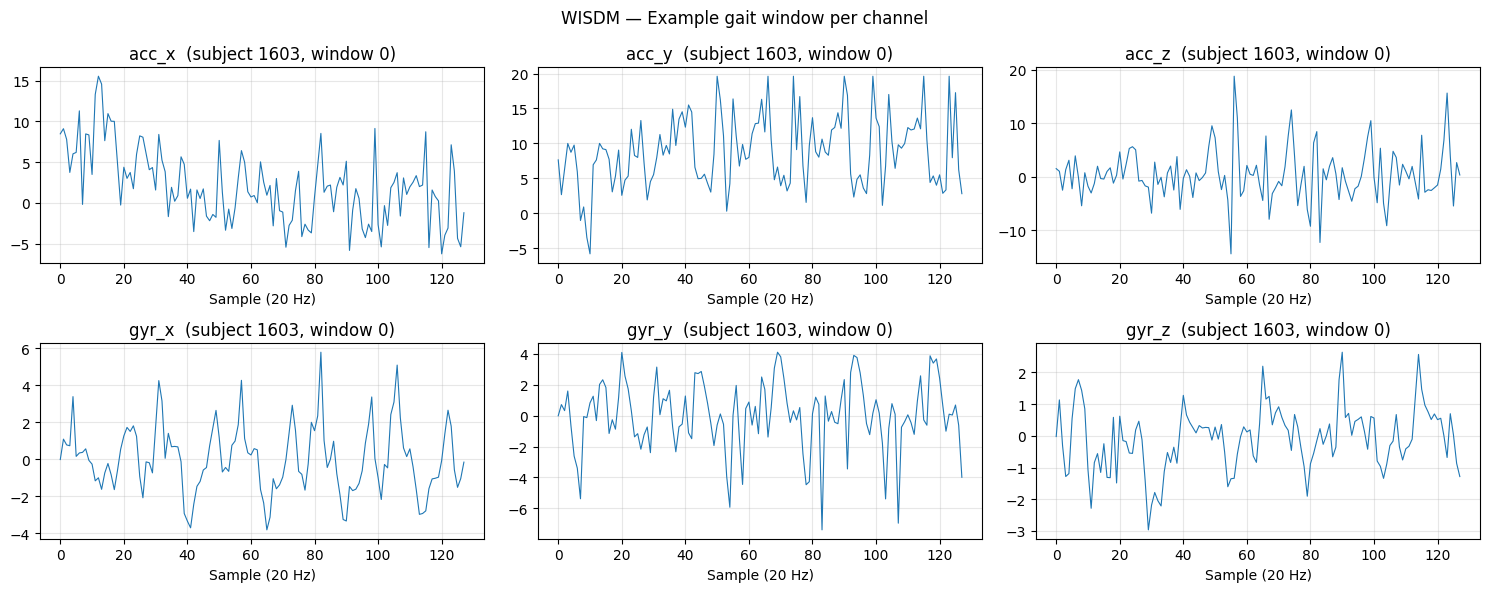

In [6]:
channel_names = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']

ch_mean = X_train.mean(axis=(0, 2))
ch_std  = X_train.std(axis=(0, 2))

for name, m, s in zip(channel_names, ch_mean, ch_std):
    log.info(f'  {name:8s}  mean={m:+.4f}  std={s:.4f}')

fig, axes = plt.subplots(2, 3, figsize=(15, 6))
for i, (ax, name) in enumerate(zip(axes.flat, channel_names)):
    sample_subj = member_ids[0]
    win = X_train[y_train == sample_subj][0, i]
    ax.plot(win, linewidth=0.8)
    ax.set_title(f'{name}  (subject {sample_subj}, window 0)')
    ax.set_xlabel('Sample (20 Hz)')
    ax.grid(True, alpha=0.3)
plt.suptitle('WISDM — Example gait window per channel')
plt.tight_layout()
plt.savefig(RESULT_DIR / '01_example_window.png', dpi=150)
plt.show()

## 5. Build Authentication Pairs

Same structure as UCI-HAR: 30k same + 30k different pairs for train, 5k + 5k for test.

In [ ]:
N_TRAIN_PAIRS = 30000
N_TEST_PAIRS  =  5000

X1_tr, X2_tr, y_tr, subj1_tr, subj2_tr = build_auth_pairs(
    X_train, y_train, n_pairs_per_class=N_TRAIN_PAIRS, seed=42)
X1_te, X2_te, y_te, subj1_te, subj2_te = build_auth_pairs(
    X_test,  y_test,  n_pairs_per_class=N_TEST_PAIRS,  seed=42)

log.info(f'Train pairs: {len(y_tr)} total  (same={int((y_tr==0).sum())}, diff={int((y_tr==1).sum())})')
log.info(f'Test  pairs: {len(y_te)} total  (same={int((y_te==0).sum())}, diff={int((y_te==1).sum())})')

# Contamination check
member_set    = set(member_ids)
nonmember_set = set(nonmember_ids)
assert set(subj1_tr.tolist() + subj2_tr.tolist()) <= member_set,    'Train pairs contain non-member subjects!'
assert set(subj1_te.tolist() + subj2_te.tolist()) <= nonmember_set, 'Test pairs contain member subjects!'
log.info('Contamination check passed')

np.savez_compressed(
    ARTIFACT_DIR / 'auth_pairs.npz',
    X1_tr=X1_tr,    X2_tr=X2_tr,    y_tr=y_tr,
    subj1_tr=subj1_tr, subj2_tr=subj2_tr,
    X1_te=X1_te,    X2_te=X2_te,    y_te=y_te,
    subj1_te=subj1_te, subj2_te=subj2_te,
)
log.info(f'Saved: {ARTIFACT_DIR}/auth_pairs.npz')

## 6. Pair Correlation Analysis

Same-person corr:  mean=-0.002  std=0.223
Diff-person corr:  mean=0.001  std=0.067


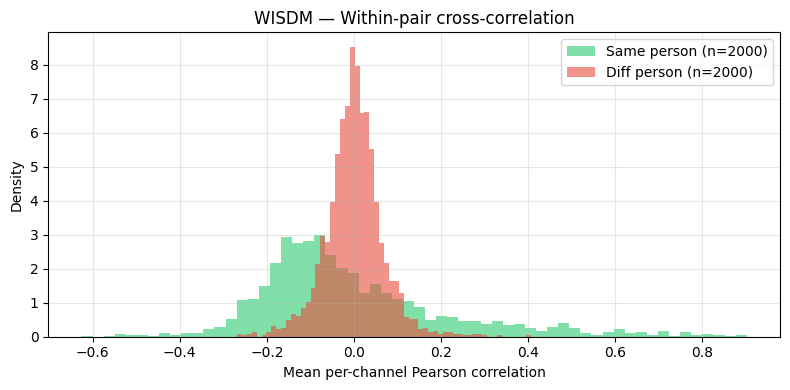

In [8]:
def pair_corr(X1, X2):
    corrs = []
    for i in range(len(X1)):
        ch_corrs = [float(np.corrcoef(X1[i, c], X2[i, c])[0, 1]) for c in range(X1.shape[1])]
        corrs.append(np.mean(ch_corrs))
    return np.array(corrs)

sample = 2000
same_mask = y_tr == 0
diff_mask = y_tr == 1

corr_same = pair_corr(X1_tr[same_mask][:sample], X2_tr[same_mask][:sample])
corr_diff = pair_corr(X1_tr[diff_mask][:sample], X2_tr[diff_mask][:sample])

log.info(f'Same-person corr:  mean={corr_same.mean():.3f}  std={corr_same.std():.3f}')
log.info(f'Diff-person corr:  mean={corr_diff.mean():.3f}  std={corr_diff.std():.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(corr_same, bins=60, alpha=0.6, color='#2ecc71', label=f'Same person (n={sample})', density=True)
ax.hist(corr_diff, bins=60, alpha=0.6, color='#e74c3c', label=f'Diff person (n={sample})', density=True)
ax.set_xlabel('Mean per-channel Pearson correlation')
ax.set_ylabel('Density')
ax.set_title('WISDM — Within-pair cross-correlation')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULT_DIR / '01_pair_correlation.png', dpi=150)
plt.show()

## 7. Summary

In [9]:
summary = f"""
=== NB01 WISDM SUMMARY ===

Total subjects:      {len(all_subjects)}  (IDs {min(all_subjects)}–{max(all_subjects)})
Members (train CNN): {len(member_ids)}
Non-members (test):  {len(nonmember_ids)}

Walking windows:     {len(y_all)} total
  Member windows:    {len(y_train)}
  Non-member:        {len(y_test)}
  Per-subject mean:  {np.mean(list(windows_per_subject.values())):.1f}

Window size:         128 samples at 20 Hz = 6.4 s
Stride:              64 samples (50% overlap)
Channels:            6 (acc xyz + gyr xyz)

Auth pairs (train):  {len(y_tr)} ({(y_tr==0).sum()} same + {(y_tr==1).sum()} diff)
Auth pairs (test):   {len(y_te)} ({(y_te==0).sum()} same + {(y_te==1).sum()} diff)

Pair correlation:
  Same-person: mean={corr_same.mean():.3f}  std={corr_same.std():.3f}
  Diff-person: mean={corr_diff.mean():.3f}  std={corr_diff.std():.3f}
  Separation:  {corr_same.mean() - corr_diff.mean():.3f}

Saved:
  logs/wisdm/subject_split.json
  logs/wisdm/auth_pairs.npz
"""
print(summary)
log.info(summary)

write_latex_metrics('nb01_wisdm', {
    'wisdmTotalSubjects':     len(all_subjects),
    'wisdmMemberSubjects':    len(member_ids),
    'wisdmNonmemberSubjects': len(nonmember_ids),
    'wisdmTotalWindows':      len(y_all),
    'wisdmMemberWindows':     len(y_train),
    'wisdmWindowSamples':     128,
    'wisdmSamplingHz':        20,
    'wisdmWindowSec':         '6.4',
    'wisdmTrainPairs':        len(y_tr),
    'wisdmTestPairs':         len(y_te),
    'wisdmSameCorr':          f'{corr_same.mean():.3f}',
    'wisdmDiffCorr':          f'{corr_diff.mean():.3f}',
}, output_dir='../latex/generated', log=log, key_prefix='wisdm')


=== NB01 WISDM SUMMARY ===

Total subjects:      51  (IDs 1600–1650)
Members (train CNN): 40
Non-members (test):  11

Walking windows:     3101 total
  Member windows:    2422
  Non-member:        679
  Per-subject mean:  60.8

Window size:         128 samples at 20 Hz = 6.4 s
Stride:              64 samples (50% overlap)
Channels:            6 (acc xyz + gyr xyz)

Auth pairs (train):  60000 (30000 same + 30000 diff)
Auth pairs (test):   10000 (5000 same + 5000 diff)

Pair correlation:
  Same-person: mean=-0.002  std=0.223
  Diff-person: mean=0.001  std=0.067
  Separation:  -0.003

Saved:
  logs/wisdm/subject_split.json
  logs/wisdm/auth_pairs.npz

LaTeX metrics written: ../latex/generated/nb01_wisdm_metrics.tex



=== NB01 WISDM SUMMARY ===

Total subjects:      51  (IDs 1600–1650)
Members (train CNN): 40
Non-members (test):  11

Walking windows:     3101 total
  Member windows:    2422
  Non-member:        679
  Per-subject mean:  60.8

Window size:         128 samples at 20 Hz = 6.4 s
Stride:              64 samples (50% overlap)
Channels:            6 (acc xyz + gyr xyz)

Auth pairs (train):  60000 (30000 same + 30000 diff)
Auth pairs (test):   10000 (5000 same + 5000 diff)

Pair correlation:
  Same-person: mean=-0.002  std=0.223
  Diff-person: mean=0.001  std=0.067
  Separation:  -0.003

Saved:
  logs/wisdm/subject_split.json
  logs/wisdm/auth_pairs.npz

